In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ----------------------------
# Load
# ----------------------------
PATH = Path("/Users/joshmacbook/python_projects/OAD/Data/in Use/combined_rounds_all_2017_2025.csv")
df = pd.read_csv(PATH)

# ----------------------------
# Schema checks
# ----------------------------
required = ["year","event_id","dg_id","round_num","course_num","finish_num","event_completed","event_name","tour"]
missing = sorted(set(required) - set(df.columns))
assert not missing, f"Missing required columns: {missing}"

# ----------------------------
# Core normalization
# ----------------------------
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["event_id"] = pd.to_numeric(df["event_id"], errors="coerce").astype("Int64")
df["dg_id"] = pd.to_numeric(df["dg_id"], errors="coerce").astype("Int64")
df["round_num"] = pd.to_numeric(df["round_num"], errors="coerce").astype("Int64")
df["course_num"] = pd.to_numeric(df["course_num"], errors="coerce").astype("Int64")
df["event_completed"] = pd.to_datetime(df["event_completed"], errors="coerce")

# ----------------------------
# OAD event ids
# ----------------------------
OAD_EVENT_IDS = {
    11, 7, 9, 23, 5, 12, 480, 26, 34, 14, 33, 100, 19, 32, 41, 524,
    20, 21, 4, 10, 541, 3, 2, 475, 6, 525, 30, 13, 540, 27, 28
}

# ----------------------------
# Primary course overrides
# ----------------------------
PRIMARY_COURSE_BY_EVENT = {
    2: 704,
    4: 4,
    5: 5,
}

# ----------------------------
# Filter to OAD events
# ----------------------------
df_t = df[df["event_id"].isin(OAD_EVENT_IDS)].copy()

# ----------------------------
# Apply primary course logic
# ----------------------------
df_t["course_num_effective"] = df_t["event_id"].map(PRIMARY_COURSE_BY_EVENT)
df_t["course_num_effective"] = df_t["course_num_effective"].fillna(df_t["course_num"]).astype("Int64")

# ----------------------------
# Field definition: round-1 starters (full pre-cut field)
# ----------------------------
starters = (
    df_t[df_t["round_num"] == 1]
    .dropna(subset=["year","event_id","dg_id"])
    .drop_duplicates(subset=["year","event_id","dg_id"])
)

event_spine = (
    starters.groupby(["year","event_id"], as_index=False)
    .agg(
        field_n=("dg_id", "count"),
        course_num=("course_num_effective", "first"),
        event_name=("event_name", "first"),
        tour=("tour", "first"),
        event_completed=("event_completed", "max"),
    )
    .sort_values(["year","event_completed","event_id"])
    .reset_index(drop=True)
)

print("Target OAD events (year-event):", len(event_spine))
display(event_spine.head(20))

Target OAD events (year-event): 254


,year,event_id,field_n,course_num,event_name,tour,event_completed
0,2017,6,144,6,Sony Open in Hawaii,PGA,2017-01-15
1,2017,2,156,704,CareerBuilder Challenge,PGA,2017-01-22
2,2017,4,156,4,Farmers Insurance Open,PGA,2017-01-29
3,2017,3,131,510,Waste Management Phoenix Open,PGA,2017-02-05
4,2017,5,155,5,AT&T Pebble Beach Pro-Am,PGA,2017-02-12
5,2017,7,144,500,Genesis Open,PGA,2017-02-19
6,2017,10,142,734,The Honda Classic,PGA,2017-02-26
7,2017,475,144,665,Valspar Championship,PGA,2017-03-12
8,2017,9,120,9,Arnold Palmer Invitational presented by Master...,PGA,2017-03-19
9,2017,20,144,729,Shell Houston Open,PGA,2017-04-02


In [5]:
# ----------------------------
# Helpers
# ----------------------------
def _parse_finish_num(x):
    """
    Convert finish text to numeric rank.
    Examples:
      'T12' -> 12
      '12'  -> 12
      'CUT','WD','DQ' -> NaN
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if s.startswith("T"):
        s = s[1:]
    try:
        return float(s)
    except Exception:
        return np.nan


# ----------------------------
# Build starters (full pre-cut field)
# ----------------------------
starters = (
    df_t[df_t["round_num"] == 1]
    .dropna(subset=["year","event_id","dg_id"])
    .drop_duplicates(subset=["year","event_id","dg_id"])
    .merge(
        event_spine[["year","event_id","field_n"]],
        on=["year","event_id"],
        how="left",
        validate="many_to_one",
    )
)

# ----------------------------
# Build finish positions
# ----------------------------
fin = (
    df_t[["year","event_id","dg_id","finish_num"]]
    .drop_duplicates(subset=["year","event_id","dg_id"])
    .copy()
)

fin["finish_pos"] = fin["finish_num"].map(_parse_finish_num)

# ----------------------------
# Join starters + finishes
# ----------------------------
labels = starters.merge(
    fin[["year","event_id","dg_id","finish_pos"]],
    on=["year","event_id","dg_id"],
    how="left",
    validate="one_to_one",
)

# ----------------------------
# Compute top-10% threshold per event
# ----------------------------
labels["top_n"] = np.ceil(0.10 * labels["field_n"]).astype(int)

# ----------------------------
# Label: top 10% of full field
# ----------------------------
labels["is_top10pct"] = (
    labels["finish_pos"].notna()
    & (labels["finish_pos"] <= labels["top_n"])
)

# ----------------------------
# Final label table
# ----------------------------
labels = labels[
    ["year","event_id","dg_id","field_n","top_n","finish_pos","is_top10pct"]
].sort_values(["year","event_id","finish_pos","dg_id"]).reset_index(drop=True)

print("Label rows:", len(labels))
print("Overall top10% rate:", labels["is_top10pct"].mean())
display(labels.head(20))


Label rows: 34632
Overall top10% rate: 0.11905174405174405


,year,event_id,dg_id,field_n,top_n,finish_pos,is_top10pct
0,2017,2,14706,156,16,1.0,True
1,2017,2,13965,156,16,2.0,True
2,2017,2,8825,156,16,3.0,True
3,2017,2,14502,156,16,3.0,True
4,2017,2,17564,156,16,5.0,True
5,2017,2,6248,156,16,6.0,True
6,2017,2,11019,156,16,6.0,True
7,2017,2,12359,156,16,8.0,True
8,2017,2,7626,156,16,9.0,True
9,2017,2,9586,156,16,9.0,True


In [6]:
WINDOWS = [12, 24, 40, 100]

def build_rolling_features_single_event(
    rounds_df: pd.DataFrame,
    dg_ids: list[int],
    cutoff_ts,
    value_cols: list[str],
    windows=WINDOWS,
) -> pd.DataFrame:
    # enforce ordering
    r = (
        rounds_df
        .sort_values(["dg_id","event_completed","round_num"])
        .copy()
    )

    out = pd.DataFrame({"dg_id": dg_ids})

    for w in windows:
        tail = (
            r
            .groupby("dg_id", as_index=False, sort=False)
            .tail(w)
        )

        agg = tail.groupby("dg_id", as_index=False)[value_cols].agg(["mean","std","count"])

        # flatten
        agg.columns = [
            f"{c}_L{w}_{stat}" if stat else c
            for c, stat in [
                (col[0], col[1]) if isinstance(col, tuple) else (col, "")
                for col in agg.columns
            ]
        ]
        agg = agg.rename(columns={c: c.replace("_count","_n") for c in agg.columns})

        out = out.merge(agg, on="dg_id", how="left")

    return out

In [7]:
WINDOWS = [12, 24, 40, 100]

def build_features_for_event(row, df_all: pd.DataFrame, value_cols: list[str], windows=WINDOWS) -> pd.DataFrame:
    yr = int(row["year"])
    eid = int(row["event_id"])
    cutoff = row["event_completed"]
    course_num = int(row["course_num"])
    field_n = int(row["field_n"])

    # full pre-cut field = round 1 starters
    field_dg_ids = (
        df_all[
            (df_all["year"] == yr) &
            (df_all["event_id"] == eid) &
            (df_all["round_num"] == 1)
        ]["dg_id"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )

    # all prior rounds across all tours/events for those players
    prior = df_all[
        (df_all["event_completed"] < cutoff) &
        (df_all["dg_id"].isin(field_dg_ids))
    ].copy()

    # if no prior rounds exist at all (rare), still return dg_ids with NaNs
    if prior.empty:
        base = pd.DataFrame({"dg_id": field_dg_ids})
    else:
        base = prior.sort_values(["dg_id","event_completed","round_num"]).copy()

    out = pd.DataFrame({"dg_id": field_dg_ids})

    for w in windows:
        if base.empty:
            agg = pd.DataFrame({"dg_id": field_dg_ids})
        else:
            tail = base.groupby("dg_id", as_index=False, sort=False).tail(w)
            agg = tail.groupby("dg_id", as_index=False)[value_cols].agg(["mean","std","count"])

            agg.columns = [
                f"{c}_L{w}_{stat}" if stat else c
                for c, stat in [
                    (col[0], col[1]) if isinstance(col, tuple) else (col, "")
                    for col in agg.columns
                ]
            ]
            agg = agg.rename(columns={c: c.replace("_count","_n") for c in agg.columns})

        out = out.merge(agg, on="dg_id", how="left")

    # attach event keys
    out.insert(0, "year", yr)
    out.insert(1, "event_id", eid)
    out.insert(2, "course_num", course_num)
    out.insert(3, "event_completed", cutoff)
    out.insert(4, "field_n", field_n)

    return out


# ----------------------------
# Choose value columns schema-driven from FULL df (not per-event)
# ----------------------------
numeric_cols = df.select_dtypes(include="number").columns.tolist()
non_feature_cols = {"year","season","event_id","dg_id","round_num","course_num"}
sg_cols = [c for c in numeric_cols if c.startswith("sg_")]
other_num_cols = [c for c in numeric_cols if c not in non_feature_cols and c not in sg_cols]
value_cols = sg_cols + other_num_cols

print("Using", len(value_cols), "numeric feature columns.")
print("Windows:", WINDOWS)

# ----------------------------
# Build all features (loop)
# ----------------------------
parts = []
for i, row in event_spine.iterrows():
    f = build_features_for_event(row, df_all=df, value_cols=value_cols, windows=WINDOWS)
    parts.append(f)

features_all = pd.concat(parts, ignore_index=True)

print("features_all rows:", len(features_all))
print("features_all cols:", len(features_all.columns))
display(features_all.head())

# ----------------------------
# Join to labels
# ----------------------------
model_df = features_all.merge(
    labels[["year","event_id","dg_id","is_top10pct","finish_pos","top_n"]],
    on=["year","event_id","dg_id"],
    how="left",
    validate="one_to_one",
)

print("model_df rows:", len(model_df))
print("Top10% rate:", model_df["is_top10pct"].mean())

Using 22 numeric feature columns.
Windows: [12, 24, 40, 100]
features_all rows: 34632
features_all cols: 270


,year,event_id,course_num,event_completed,field_n,dg_id,sg_putt_L12_mean,sg_putt_L12_std,sg_putt_L12_n,sg_arg_L12_mean,...,birdies_L100_n,pars_L100_mean,pars_L100_std,pars_L100_n,bogies_L100_mean,bogies_L100_std,bogies_L100_n,doubles_or_worse_L100_mean,doubles_or_worse_L100_std,doubles_or_worse_L100_n
0,2017,6,6,2017-01-15,144,14577,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017,6,6,2017-01-15,144,12149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017,6,6,2017-01-15,144,7744,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017,6,6,2017-01-15,144,15611,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017,6,6,2017-01-15,144,7881,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


model_df rows: 34632
Top10% rate: 0.11905174405174405


In [8]:
# ----------------------------
# Identify rolling MEAN features only
# ----------------------------
mean_cols = [c for c in model_df.columns if c.endswith("_mean")]

print("Rolling mean features:", len(mean_cols))
mean_cols[:10]

Rolling mean features: 88


['sg_putt_L12_mean',
 'sg_arg_L12_mean',
 'sg_app_L12_mean',
 'sg_ott_L12_mean',
 'sg_t2g_L12_mean',
 'sg_total_L12_mean',
 'course_par_L12_mean',
 'start_hole_L12_mean',
 'round_score_L12_mean',
 'driving_dist_L12_mean']

In [9]:
def add_event_percentiles(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()

    for c in cols:
        out[f"pct_{c}"] = (
            out
            .groupby(["year","event_id"])[c]
            .rank(pct=True)
        )

    return out

In [10]:
pct_df = add_event_percentiles(model_df, mean_cols)

BASELINE = pct_df["is_top10pct"].mean()
print("Baseline top10% rate:", BASELINE)

Baseline top10% rate: 0.11905174405174405


In [11]:
rows = []

for c in mean_cols:
    pct_col = f"pct_{c}"

    tmp = pct_df[pct_df[pct_col].notna()].copy()
    if tmp.empty:
        continue

    top_decile = tmp[tmp[pct_col] >= 0.90]

    if len(top_decile) < 50:
        continue  # avoid noise

    rows.append({
        "feature": c,
        "n_players": len(tmp),
        "top_decile_rate": top_decile["is_top10pct"].mean(),
        "lift_vs_baseline": top_decile["is_top10pct"].mean() / BASELINE
    })

global_lift = (
    pd.DataFrame(rows)
    .sort_values("lift_vs_baseline", ascending=False)
    .reset_index(drop=True)
)

display(global_lift.head(25))

,feature,n_players,top_decile_rate,lift_vs_baseline
0,sg_total_L100_mean,33705,0.304422,2.557054
1,sg_total_L40_mean,33705,0.292234,2.454677
2,sg_total_L24_mean,33705,0.289966,2.435630
3,sg_t2g_L100_mean,33178,0.286496,2.406482
4,sg_t2g_L40_mean,32905,0.286337,2.405149
5,sg_t2g_L24_mean,32784,0.277583,2.331618
6,sg_total_L12_mean,33705,0.261128,2.193403
7,sg_t2g_L12_mean,32521,0.254337,2.136356
8,birdies_L100_mean,33703,0.250497,2.104102
9,birdies_L40_mean,33703,0.238394,2.002437


In [12]:
rows = []

for course, g in pct_df.groupby("course_num"):
    base_course = g["is_top10pct"].mean()
    if base_course == 0 or np.isnan(base_course):
        continue

    events_used = g[["year","event_id"]].drop_duplicates().shape[0]

    for c in mean_cols:
        pct_col = f"pct_{c}"
        if pct_col not in g.columns:
            continue

        tmp = g[g[pct_col].notna()]
        if tmp.empty:
            continue

        top_decile = tmp[tmp[pct_col] >= 0.90]
        if len(top_decile) < 10:
            continue  # ultra-noisy, but still included via events_used

        rows.append({
            "course_num": course,
            "feature": c,
            "events_used": events_used,
            "players_used": len(tmp),
            "top_decile_rate": top_decile["is_top10pct"].mean(),
            "lift_vs_course_baseline": top_decile["is_top10pct"].mean() / base_course
        })

course_lift = (
    pd.DataFrame(rows)
    .sort_values(["course_num","lift_vs_course_baseline"], ascending=[True, False])
    .reset_index(drop=True)
)

display(course_lift.head(30))

,course_num,feature,events_used,players_used,top_decile_rate,lift_vs_course_baseline
0,4,sg_t2g_L40_mean,9,1354,0.347518,2.816300
1,4,sg_total_L100_mean,9,1368,0.335664,2.720239
2,4,sg_t2g_L100_mean,9,1356,0.333333,2.701349
3,4,sg_total_L40_mean,9,1368,0.321678,2.606896
4,4,sg_total_L24_mean,9,1368,0.314685,2.550224
5,4,birdies_L24_mean,9,1368,0.297872,2.413971
6,4,birdies_L100_mean,9,1368,0.296552,2.403269
7,4,birdies_L40_mean,9,1368,0.288732,2.339901
8,4,driving_dist_L40_mean,9,1356,0.283688,2.299020
9,4,sg_ott_L100_mean,9,1356,0.283688,2.299020


In [13]:
import re

def parse_stat_window(col):
    """
    sg_total_L12_mean -> (sg_total, L12)
    """
    m = re.match(r"(.*)_L(\d+)_mean", col)
    if not m:
        return None, None
    return m.group(1), f"L{m.group(2)}"

stat_window_map = {
    c: parse_stat_window(c)
    for c in mean_cols
}

# drop anything malformed
stat_window_map = {
    c: v for c, v in stat_window_map.items()
    if v[0] is not None
}

In [14]:
rows = []

for col, (stat, window) in stat_window_map.items():
    pct_col = f"pct_{col}"
    if pct_col not in pct_df.columns:
        continue

    tmp = pct_df[pct_df[pct_col].notna()]
    if tmp.empty:
        continue

    top_decile = tmp[tmp[pct_col] >= 0.90]
    if len(top_decile) < 50:
        continue

    rows.append({
        "stat": stat,
        "window": window,
        "top_decile_rate": top_decile["is_top10pct"].mean(),
        "lift_vs_baseline": top_decile["is_top10pct"].mean() / BASELINE,
        "n_players": len(tmp),
    })

window_lift = pd.DataFrame(rows)

In [15]:
window_rank = (
    window_lift
    .sort_values(["stat","lift_vs_baseline"], ascending=[True, False])
    .reset_index(drop=True)
)

display(window_rank.head(30))

,stat,window,top_decile_rate,lift_vs_baseline,n_players
0,birdies,L100,0.250497,2.104102,33703
1,birdies,L40,0.238394,2.002437,33703
2,birdies,L24,0.218581,1.836015,33703
3,birdies,L12,0.202550,1.701357,33703
4,bogies,L12,0.062267,0.523023,33703
5,bogies,L24,0.047537,0.399299,33703
6,bogies,L40,0.044205,0.371310,33703
7,bogies,L100,0.037258,0.312958,33703
8,course_par,L12,0.145617,1.223137,33704
9,course_par,L24,0.132191,1.110362,33704


In [16]:
preferred_window = (
    window_rank
    .groupby("stat", as_index=False)
    .first()
    .rename(columns={
        "window": "preferred_window",
        "lift_vs_baseline": "preferred_lift"
    })
    .sort_values("preferred_lift", ascending=False)
)

display(preferred_window.head(20))

,stat,preferred_window,top_decile_rate,preferred_lift,n_players
20,sg_total,L100,0.304422,2.557054,33705
19,sg_t2g,L100,0.286496,2.406482,33178
0,birdies,L100,0.250497,2.104102,33703
17,sg_ott,L40,0.235465,1.977838,32905
15,sg_app,L100,0.219407,1.842954,33178
8,great_shots,L100,0.194805,1.636307,33145
7,gir,L24,0.193652,1.626618,32882
5,driving_dist,L40,0.193155,1.622450,32964
6,eagles_or_better,L100,0.172229,1.446669,33703
16,sg_arg,L100,0.171848,1.443473,33178


In [17]:
mean_cols = [c for c in model_df.columns if c.endswith("_mean")]
std_cols  = [c for c in model_df.columns if c.endswith("_std")]

# map mean -> std
mean_to_std = {}
for m in mean_cols:
    s = m.replace("_mean", "_std")
    if s in std_cols:
        mean_to_std[m] = s

len(mean_to_std)

88

In [18]:
pct_df2 = pct_df.copy()

for m, s in mean_to_std.items():
    # percentile of mean (already exists)
    # percentile of std (lower is better)
    pct_df2[f"pct_{s}"] = (
        pct_df2
        .groupby(["year","event_id"])[s]
        .rank(pct=True, ascending=False)
    )

In [19]:
rows = []

for m, s in mean_to_std.items():
    pct_m = f"pct_{m}"
    pct_s = f"pct_{s}"

    if pct_m not in pct_df2.columns or pct_s not in pct_df2.columns:
        continue

    # Mean-based
    top_mean = pct_df2[pct_df2[pct_m] >= 0.90]
    if len(top_mean) >= 50:
        rows.append({
            "stat": m.replace("_mean",""),
            "metric": "mean",
            "lift": top_mean["is_top10pct"].mean() / BASELINE,
            "n": len(top_mean),
        })

    # Consistency-based
    top_cons = pct_df2[pct_df2[pct_s] >= 0.90]
    if len(top_cons) >= 50:
        rows.append({
            "stat": m.replace("_mean",""),
            "metric": "consistency",
            "lift": top_cons["is_top10pct"].mean() / BASELINE,
            "n": len(top_cons),
        })

volatility_cmp = pd.DataFrame(rows)

In [20]:
volatility_rank = (
    volatility_cmp
    .pivot_table(
        index="stat",
        columns="metric",
        values="lift"
    )
    .assign(delta=lambda x: x.get("mean", np.nan) - x.get("consistency", np.nan))
    .sort_values("delta", ascending=False)
    .reset_index()
)

display(volatility_rank.head(25))

metric,stat,consistency,mean,delta
0,birdies_L100,0.583479,2.104102,1.520624
1,sg_total_L100,1.071695,2.557054,1.485359
2,sg_t2g_L100,0.984208,2.406482,1.422273
3,sg_t2g_L24,0.956804,2.331618,1.374814
4,sg_t2g_L40,1.032831,2.405149,1.372318
5,sg_total_L40,1.107418,2.454677,1.347258
6,sg_total_L24,1.128852,2.435630,1.306778
7,birdies_L40,0.714666,2.002437,1.287771
8,sg_t2g_L12,0.980752,2.136356,1.155604
9,sg_total_L12,1.069314,2.193403,1.124089


In [21]:
def infer_tier(event_name: str) -> str:
    s = str(event_name).lower()
    if any(k in s for k in ["masters", "u.s. open", "us open", "pga championship", "open championship"]):
        return "major"
    if any(k in s for k in ["signature", "players championship", "arnold palmer", "memorial"]):
        return "signature"
    return "regular"

tier_map = (
    event_spine[["year","event_id","event_name"]]
    .drop_duplicates()
    .assign(tier=lambda x: x["event_name"].apply(infer_tier))
)

pct_df_tier = pct_df.merge(
    tier_map[["year","event_id","tier"]],
    on=["year","event_id"],
    how="left",
    validate="many_to_one",
)

pct_df_tier["tier"].value_counts()

tier
regular      26746
major         4606
signature     3280
Name: count, dtype: int64

In [22]:
rows = []

for tier, g in pct_df_tier.groupby("tier"):
    base_tier = g["is_top10pct"].mean()
    if base_tier == 0 or np.isnan(base_tier):
        continue

    for c in mean_cols:
        pct_col = f"pct_{c}"
        if pct_col not in g.columns:
            continue

        tmp = g[g[pct_col].notna()]
        if tmp.empty:
            continue

        top_decile = tmp[tmp[pct_col] >= 0.90]
        if len(top_decile) < 30:
            continue

        rows.append({
            "tier": tier,
            "feature": c,
            "top_decile_rate": top_decile["is_top10pct"].mean(),
            "lift_vs_tier_baseline": top_decile["is_top10pct"].mean() / base_tier,
            "players_used": len(tmp),
        })

tier_lift = (
    pd.DataFrame(rows)
    .sort_values(["tier","lift_vs_tier_baseline"], ascending=[True, False])
    .reset_index(drop=True)
)

display(tier_lift.head(30))

,tier,feature,top_decile_rate,lift_vs_tier_baseline,players_used
0,major,sg_total_L100_mean,0.348889,2.970392,4306
1,major,sg_total_L40_mean,0.333333,2.837954,4306
2,major,sg_t2g_L100_mean,0.331731,2.824310,3990
3,major,sg_t2g_L40_mean,0.330864,2.816933,3900
4,major,sg_t2g_L24_mean,0.325000,2.767006,3841
5,major,birdies_L100_mean,0.303769,2.586251,4306
6,major,sg_ott_L24_mean,0.302500,2.575444,3841
7,major,sg_total_L24_mean,0.297778,2.535239,4306
8,major,sg_ott_L40_mean,0.296296,2.522626,3900
9,major,sg_t2g_L12_mean,0.288265,2.454251,3737


In [23]:
tier_rank = (
    tier_lift
    .groupby("tier", as_index=False)
    .head(15)
)

display(tier_rank)

,tier,feature,top_decile_rate,lift_vs_tier_baseline,players_used
0,major,sg_total_L100_mean,0.348889,2.970392,4306
1,major,sg_total_L40_mean,0.333333,2.837954,4306
2,major,sg_t2g_L100_mean,0.331731,2.824310,3990
3,major,sg_t2g_L40_mean,0.330864,2.816933,3900
4,major,sg_t2g_L24_mean,0.325000,2.767006,3841
5,major,birdies_L100_mean,0.303769,2.586251,4306
6,major,sg_ott_L24_mean,0.302500,2.575444,3841
7,major,sg_total_L24_mean,0.297778,2.535239,4306
8,major,sg_ott_L40_mean,0.296296,2.522626,3900
9,major,sg_t2g_L12_mean,0.288265,2.454251,3737


In [24]:
import re

def parse_stat_window(col):
    m = re.match(r"(.*)_L(\d+)_mean", col)
    if not m:
        return None, None
    return m.group(1), f"L{m.group(2)}"

stat_window_map = {
    c: parse_stat_window(c)
    for c in mean_cols
}

stat_window_map = {
    c: v for c, v in stat_window_map.items()
    if v[0] is not None
}

rows = []

for course, g in pct_df.groupby("course_num"):
    base_course = g["is_top10pct"].mean()
    if base_course == 0 or np.isnan(base_course):
        continue

    events_used = g[["year","event_id"]].drop_duplicates().shape[0]

    for col, (stat, window) in stat_window_map.items():
        pct_col = f"pct_{col}"
        if pct_col not in g.columns:
            continue

        tmp = g[g[pct_col].notna()]
        if tmp.empty:
            continue

        top_decile = tmp[tmp[pct_col] >= 0.90]
        if len(top_decile) < 10:
            continue

        rows.append({
            "course_num": course,
            "stat": stat,
            "window": window,
            "events_used": events_used,
            "players_used": len(tmp),
            "top_decile_rate": top_decile["is_top10pct"].mean(),
            "lift_vs_course_baseline": top_decile["is_top10pct"].mean() / base_course,
        })

course_window_lift = (
    pd.DataFrame(rows)
    .sort_values(
        ["course_num","stat","lift_vs_course_baseline"],
        ascending=[True, True, False]
    )
    .reset_index(drop=True)
)

display(course_window_lift.head(30))

preferred_course_window = (
    course_window_lift
    .groupby(["course_num","stat"], as_index=False)
    .first()
    .rename(columns={
        "window": "preferred_window",
        "lift_vs_course_baseline": "preferred_lift"
    })
    .sort_values(["course_num","preferred_lift"], ascending=[True, False])
)

display(preferred_course_window.head(30))

,course_num,stat,window,events_used,players_used,top_decile_rate,lift_vs_course_baseline
0,4,birdies,L24,9,1368,0.297872,2.413971
1,4,birdies,L100,9,1368,0.296552,2.403269
2,4,birdies,L40,9,1368,0.288732,2.339901
3,4,birdies,L12,9,1368,0.265734,2.153523
4,4,bogies,L12,9,1368,0.084507,0.684849
5,4,bogies,L40,9,1368,0.063380,0.513637
6,4,bogies,L24,9,1368,0.049645,0.402329
7,4,bogies,L100,9,1368,0.041958,0.340030
8,4,course_par,L12,9,1368,0.257812,2.089324
9,4,course_par,L24,9,1368,0.194030,1.572427


,course_num,stat,preferred_window,events_used,players_used,top_decile_rate,preferred_lift
19,4,sg_t2g,L40,9,1354,0.347518,2.816300
20,4,sg_total,L100,9,1368,0.335664,2.720239
0,4,birdies,L24,9,1368,0.297872,2.413971
5,4,driving_dist,L40,9,1356,0.283688,2.299020
17,4,sg_ott,L100,9,1356,0.283688,2.299020
2,4,course_par,L12,9,1368,0.257812,2.089324
7,4,gir,L24,9,1350,0.246479,1.997476
8,4,great_shots,L40,9,1354,0.234043,1.896692
6,4,eagles_or_better,L100,9,1368,0.230216,1.865680
15,4,sg_app,L100,9,1356,0.219858,1.781741


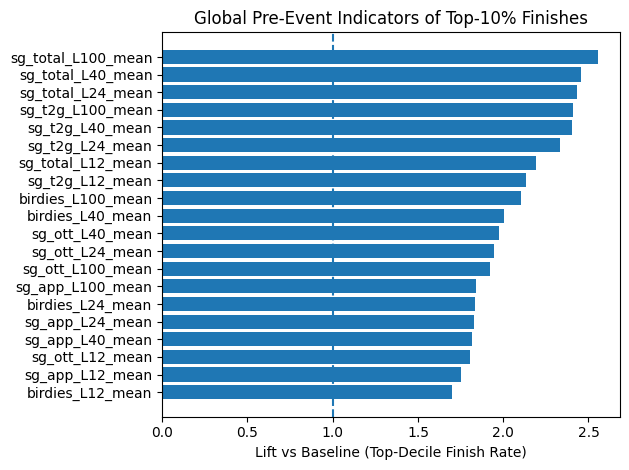

In [25]:
import matplotlib.pyplot as plt

top_n = 20
plot_df = global_lift.head(top_n).sort_values("lift_vs_baseline")

plt.figure()
plt.barh(plot_df["feature"], plot_df["lift_vs_baseline"])
plt.axvline(1.0, linestyle="--")
plt.xlabel("Lift vs Baseline (Top-Decile Finish Rate)")
plt.title("Global Pre-Event Indicators of Top-10% Finishes")
plt.tight_layout()
plt.show()

In [26]:
heat_df = (
    window_lift
    .pivot_table(
        index="stat",
        columns="window",
        values="lift_vs_baseline"
    )
    .sort_values("L12", ascending=False)
)


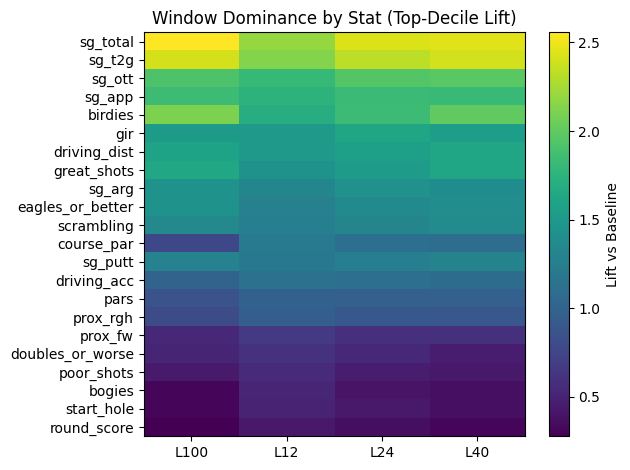

In [27]:
plt.figure()
plt.imshow(heat_df, aspect="auto")
plt.colorbar(label="Lift vs Baseline")
plt.xticks(range(len(heat_df.columns)), heat_df.columns)
plt.yticks(range(len(heat_df.index)), heat_df.index)
plt.title("Window Dominance by Stat (Top-Decile Lift)")
plt.tight_layout()
plt.show()

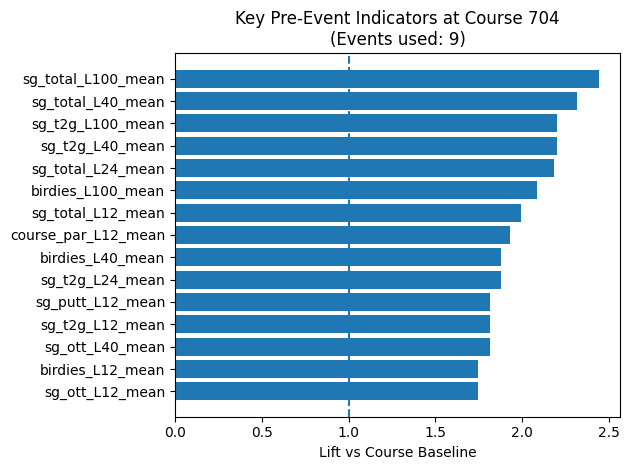

In [28]:
COURSE = 704  # example

course_df = (
    course_lift[course_lift["course_num"] == COURSE]
    .sort_values("lift_vs_course_baseline", ascending=False)
    .head(15)
    .sort_values("lift_vs_course_baseline")
)

plt.figure()
plt.barh(course_df["feature"], course_df["lift_vs_course_baseline"])
plt.axvline(1.0, linestyle="--")
plt.xlabel("Lift vs Course Baseline")
plt.title(
    f"Key Pre-Event Indicators at Course {COURSE}\n"
    f"(Events used: {course_df['events_used'].iloc[0]})"
)
plt.tight_layout()
plt.show()

# ----------

In [29]:
# ----------------------------
# Load odds and YTD tracker
# ----------------------------
from Scripts.features import compute_ytd_stats

odds_path = Path("/Users/joshmacbook/python_projects/OAD/Data/in Use/Odds_and_Results.xlsx")
tracker_path = Path("/Users/joshmacbook/python_projects/OAD/Data/in Use/ytd_tracker.csv")

odds_df = pd.read_excel(odds_path)
ytd_tracker = pd.read_csv(tracker_path)

print("Odds rows:", len(odds_df))
print("Tracker rows:", len(ytd_tracker))

Odds rows: 11990
Tracker rows: 36803


In [30]:
# ----------------------------
# Build YTD features for each OAD event
# ----------------------------
ytd_parts = []

for _, row in event_spine.iterrows():
    yr = int(row["year"])
    eid = int(row["event_id"])
    cutoff = row["event_completed"]

    ytd = compute_ytd_stats(
        rounds_df=df,
        odds_df=odds_df,
        season_year=yr,
        as_of_date=cutoff,
        ytd_tracker=ytd_tracker,
    )

    if ytd is None or ytd.empty:
        continue

    ytd = ytd.copy()
    ytd["year"] = yr
    ytd["event_id"] = eid

    ytd_parts.append(ytd)

ytd_all = pd.concat(ytd_parts, ignore_index=True)

print("YTD rows:", len(ytd_all))
display(ytd_all.head())

YTD rows: 72458


,dg_id,ytd_made_cuts,ytd_top25,ytd_top10,ytd_top5,ytd_wins,ytd_starts,ytd_made_cut_pct,ytd_avg_score,ytd_avg_sg_total,year,event_id
0,1804,0,0,0,0,0,1,0.0,69.50,-0.17050,2023,2
1,5151,0,0,0,0,0,1,0.0,70.00,-0.67050,2023,2
2,5665,1,1,0,0,0,1,1.0,67.25,1.40825,2023,2
3,6169,1,1,1,0,0,1,1.0,66.75,1.90825,2023,2
4,6252,1,1,1,0,0,1,1.0,66.75,1.90825,2023,2


In [31]:
model_df = model_df.merge(
    ytd_all,
    on=["year","event_id","dg_id"],
    how="left",
    validate="one_to_one",
)

# Confirm attachment
ytd_cols = [c for c in model_df.columns if c.startswith("ytd_")]
print(ytd_cols)

['ytd_made_cuts', 'ytd_top25', 'ytd_top10', 'ytd_top5', 'ytd_wins', 'ytd_starts', 'ytd_made_cut_pct', 'ytd_avg_score', 'ytd_avg_sg_total']


In [32]:
YTD_FEATURES = [
    "ytd_made_cut_pct",
    "ytd_top25",
    "ytd_top10",
    "ytd_top5",
    "ytd_wins",
    "ytd_avg_score",
    "ytd_avg_sg_total",
]

# keep only those that exist
YTD_FEATURES = [c for c in YTD_FEATURES if c in model_df.columns]
YTD_FEATURES

['ytd_made_cut_pct',
 'ytd_top25',
 'ytd_top10',
 'ytd_top5',
 'ytd_wins',
 'ytd_avg_score',
 'ytd_avg_sg_total']

In [33]:
df_ytd = model_df.copy()

# invert score (lower is better)
if "ytd_avg_score" in df_ytd.columns:
    df_ytd["ytd_avg_score_inv"] = -df_ytd["ytd_avg_score"]
    YTD_FEATURES = [
        c if c != "ytd_avg_score" else "ytd_avg_score_inv"
        for c in YTD_FEATURES
    ]

def event_percentile(df, col):
    return (
        df.groupby(["year","event_id"])[col]
          .rank(pct=True)
    )

for c in YTD_FEATURES:
    df_ytd[f"pct_{c}"] = event_percentile(df_ytd, c)

In [34]:
BASELINE = df_ytd["is_top10pct"].mean()
BASELINE

np.float64(0.11905174405174405)

In [35]:
def decile_lift(df, pct_col):
    tmp = df[[pct_col, "is_top10pct", "year", "event_id"]].dropna().copy()

    tmp["decile"] = (
        tmp.groupby(["year","event_id"])[pct_col]
           .transform(lambda s: pd.qcut(s, 10, labels=False, duplicates="drop"))
    )

    out = (
        tmp.groupby("decile", as_index=False)
           .agg(
               top10_rate=("is_top10pct","mean"),
               n=("is_top10pct","size")
           )
           .sort_values("decile")
    )

    out["lift_vs_baseline"] = out["top10_rate"] / BASELINE
    return out

In [36]:
import matplotlib.pyplot as plt

def plot_lift(df, pct_col, title):
    out = decile_lift(df, pct_col)

    plt.figure()
    plt.plot(out["decile"], out["top10_rate"], marker="o")
    plt.axhline(BASELINE, linestyle="--")
    plt.xlabel("Decile (higher = better)")
    plt.ylabel("Top 10% finish rate")
    plt.title(title)
    plt.show()

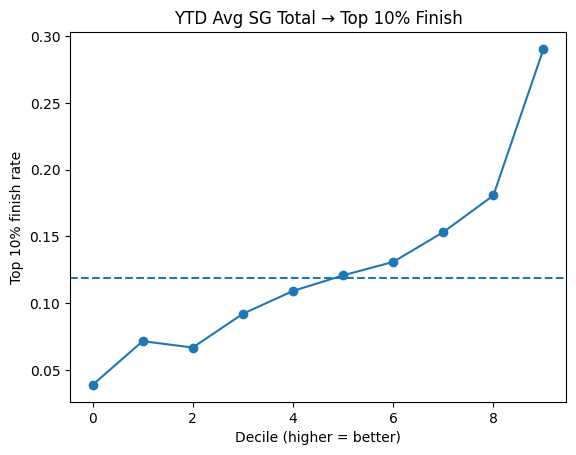

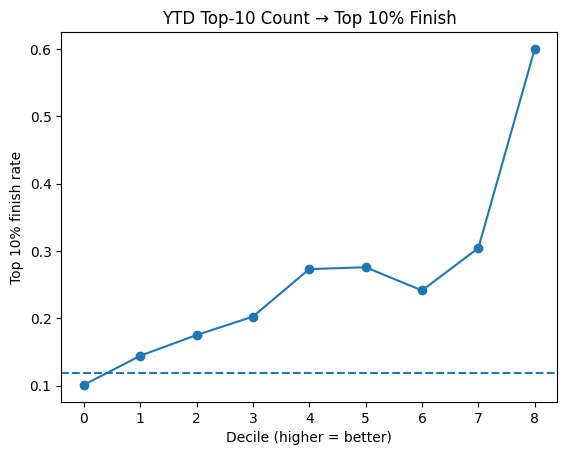

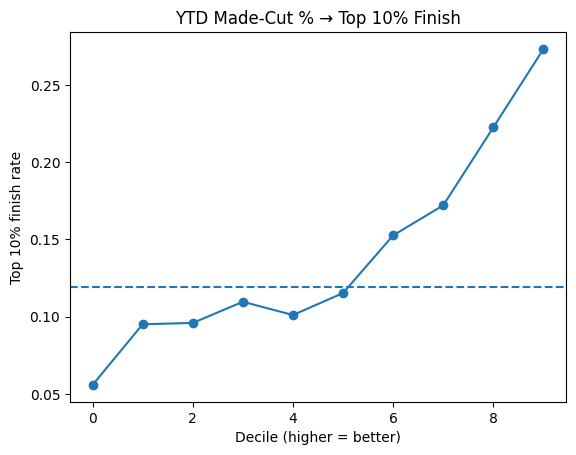

In [37]:
plot_lift(df_ytd, "pct_ytd_avg_sg_total", "YTD Avg SG Total → Top 10% Finish")

plot_lift(df_ytd, "pct_ytd_top10", "YTD Top-10 Count → Top 10% Finish")

plot_lift(df_ytd, "pct_ytd_made_cut_pct", "YTD Made-Cut % → Top 10% Finish")

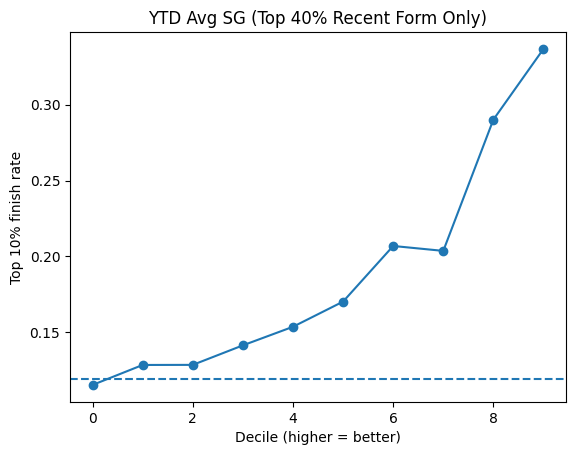

In [38]:
FORM_COL = "sg_total_L40_mean"  # or whatever window you trust most

df_cond = df_ytd[
    df_ytd[FORM_COL].notna()
].copy()

# top 40% recent form only
df_cond = df_cond[
    df_cond.groupby(["year","event_id"])[FORM_COL]
           .rank(pct=True) >= 0.60
]

plot_lift(
    df_cond,
    "pct_ytd_avg_sg_total",
    "YTD Avg SG (Top 40% Recent Form Only)"
)

In [39]:
# ----------------------------
# Build event history features (prior runnings only)
# ----------------------------
evt_parts = []

for _, row in event_spine.iterrows():
    yr = int(row["year"])
    eid = int(row["event_id"])
    cutoff = row["event_completed"]

    # prior rounds at THIS event only
    r_evt = df[
        (df["event_id"] == eid) &
        (df["event_completed"] < cutoff)
    ].copy()

    if r_evt.empty:
        continue

    # normalize finish
    r_evt["finish_pos"] = r_evt["finish_num"].map(_parse_finish_num)

    # per-event player summary
    evt = (
        r_evt.groupby("dg_id", as_index=False)
        .agg(
            evt_starts=("event_completed", "nunique"),
            evt_avg_score=("round_score", "mean"),
            evt_avg_sg_total=("sg_total", "mean"),
            evt_made_cuts=("finish_pos", lambda s: s.notna().sum()),
            evt_top25=("finish_pos", lambda s: (s <= 25).sum()),
            evt_top10=("finish_pos", lambda s: (s <= 10).sum()),
            evt_top5=("finish_pos", lambda s: (s <= 5).sum()),
            evt_wins=("finish_pos", lambda s: (s == 1).sum()),
        )
    )

    evt["evt_made_cut_pct"] = evt["evt_made_cuts"] / evt["evt_starts"]
    evt["evt_top25_rate"] = evt["evt_top25"] / evt["evt_starts"]
    evt["evt_top10_rate"] = evt["evt_top10"] / evt["evt_starts"]
    evt["evt_top5_rate"] = evt["evt_top5"] / evt["evt_starts"]
    evt["evt_win_rate"] = evt["evt_wins"] / evt["evt_starts"]

    evt["year"] = yr
    evt["event_id"] = eid

    evt_parts.append(evt)

event_hist_all = pd.concat(evt_parts, ignore_index=True)

print("Event history rows:", len(event_hist_all))
display(event_hist_all.head())

Event history rows: 61399


,dg_id,evt_starts,evt_avg_score,evt_avg_sg_total,evt_made_cuts,evt_top25,evt_top10,evt_top5,evt_wins,evt_made_cut_pct,evt_top25_rate,evt_top10_rate,evt_top5_rate,evt_win_rate,year,event_id
0,72,1,69.00,-0.692333,3,0,0,0,0,3.0,0.0,0.0,0.0,0.0,2018,6
1,493,1,70.00,-1.690500,4,0,0,0,0,4.0,0.0,0.0,0.0,0.0,2018,6
2,653,1,68.25,0.059500,4,0,0,0,0,4.0,0.0,0.0,0.0,0.0,2018,6
3,889,1,70.50,-2.191000,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2018,6
4,1804,1,71.00,-2.691000,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2018,6


In [40]:
model_df = model_df.merge(
    event_hist_all,
    on=["year","event_id","dg_id"],
    how="left",
    validate="one_to_one",
)

[c for c in model_df.columns if c.startswith("evt_")]

['evt_starts',
 'evt_avg_score',
 'evt_avg_sg_total',
 'evt_made_cuts',
 'evt_top25',
 'evt_top10',
 'evt_top5',
 'evt_wins',
 'evt_made_cut_pct',
 'evt_top25_rate',
 'evt_top10_rate',
 'evt_top5_rate',
 'evt_win_rate']

In [41]:
df_evt = model_df.copy()

# invert score
df_evt["evt_avg_score_inv"] = -df_evt["evt_avg_score"]

EVT_FEATURES = [
    "evt_starts",
    "evt_made_cut_pct",
    "evt_top25_rate",
    "evt_top10_rate",
    "evt_top5_rate",
    "evt_win_rate",
    "evt_avg_sg_total",
    "evt_avg_score_inv",
]

EVT_FEATURES = [c for c in EVT_FEATURES if c in df_evt.columns]

for c in EVT_FEATURES:
    df_evt[f"pct_{c}"] = (
        df_evt.groupby(["year","event_id"])[c]
              .rank(pct=True)
    )

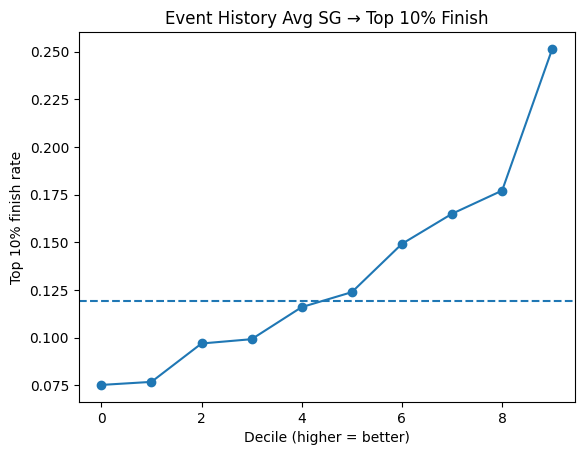

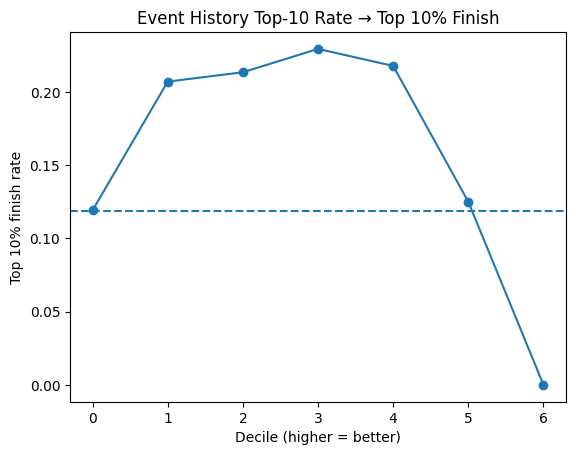

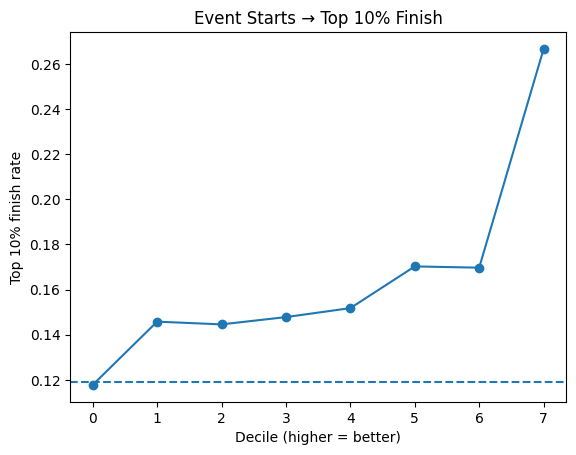

In [42]:
plot_lift(df_evt, "pct_evt_avg_sg_total", "Event History Avg SG → Top 10% Finish")

plot_lift(df_evt, "pct_evt_top10_rate", "Event History Top-10 Rate → Top 10% Finish")

plot_lift(df_evt, "pct_evt_starts", "Event Starts → Top 10% Finish")

# -----

In [43]:
# ----------------------------
# Build course history features (prior rounds at same course only)
# ----------------------------
course_parts = []

for _, row in event_spine.iterrows():
    yr = int(row["year"])
    eid = int(row["event_id"])
    cutoff = row["event_completed"]
    course_num = int(row["course_num"])

    r_course = df[
        (df["course_num"] == course_num) &
        (df["event_completed"] < cutoff)
    ].copy()

    if r_course.empty:
        continue

    r_course["finish_pos"] = r_course["finish_num"].map(_parse_finish_num)

    course = (
        r_course.groupby("dg_id", as_index=False)
        .agg(
            course_starts=("event_completed", "nunique"),
            course_avg_score=("round_score", "mean"),
            course_avg_sg_total=("sg_total", "mean"),
            course_made_cuts=("finish_pos", lambda s: s.notna().sum()),
            course_top25=("finish_pos", lambda s: (s <= 25).sum()),
            course_top10=("finish_pos", lambda s: (s <= 10).sum()),
            course_top5=("finish_pos", lambda s: (s <= 5).sum()),
            course_wins=("finish_pos", lambda s: (s == 1).sum()),
        )
    )

    course["course_made_cut_pct"] = course["course_made_cuts"] / course["course_starts"]
    course["course_top25_rate"] = course["course_top25"] / course["course_starts"]
    course["course_top10_rate"] = course["course_top10"] / course["course_starts"]
    course["course_top5_rate"] = course["course_top5"] / course["course_starts"]
    course["course_win_rate"] = course["course_wins"] / course["course_starts"]

    course["year"] = yr
    course["event_id"] = eid

    course_parts.append(course)

course_hist_all = pd.concat(course_parts, ignore_index=True)

print("Course history rows:", len(course_hist_all))
display(course_hist_all.head())

Course history rows: 47613


,dg_id,course_starts,course_avg_score,course_avg_sg_total,course_made_cuts,course_top25,course_top10,course_top5,course_wins,course_made_cut_pct,course_top25_rate,course_top10_rate,course_top5_rate,course_win_rate,year,event_id
0,72,1,69.00,-0.692333,3,0,0,0,0,3.0,0.0,0.0,0.0,0.0,2018,6
1,493,1,70.00,-1.690500,4,0,0,0,0,4.0,0.0,0.0,0.0,0.0,2018,6
2,653,1,68.25,0.059500,4,0,0,0,0,4.0,0.0,0.0,0.0,0.0,2018,6
3,889,1,70.50,-2.191000,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2018,6
4,1804,1,71.00,-2.691000,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2018,6


In [44]:
model_df = model_df.merge(
    course_hist_all,
    on=["year","event_id","dg_id"],
    how="left",
    validate="one_to_one",
)

[c for c in model_df.columns if c.startswith("course_")]

['course_num',
 'course_par_L12_mean',
 'course_par_L12_std',
 'course_par_L12_n',
 'course_par_L24_mean',
 'course_par_L24_std',
 'course_par_L24_n',
 'course_par_L40_mean',
 'course_par_L40_std',
 'course_par_L40_n',
 'course_par_L100_mean',
 'course_par_L100_std',
 'course_par_L100_n',
 'course_starts',
 'course_avg_score',
 'course_avg_sg_total',
 'course_made_cuts',
 'course_top25',
 'course_top10',
 'course_top5',
 'course_wins',
 'course_made_cut_pct',
 'course_top25_rate',
 'course_top10_rate',
 'course_top5_rate',
 'course_win_rate']

In [45]:
df_course = model_df.copy()

df_course["course_avg_score_inv"] = -df_course["course_avg_score"]

COURSE_FEATURES = [
    "course_starts",
    "course_made_cut_pct",
    "course_top25_rate",
    "course_top10_rate",
    "course_top5_rate",
    "course_win_rate",
    "course_avg_sg_total",
    "course_avg_score_inv",
]

COURSE_FEATURES = [c for c in COURSE_FEATURES if c in df_course.columns]

for c in COURSE_FEATURES:
    df_course[f"pct_{c}"] = (
        df_course.groupby(["year","event_id"])[c]
                 .rank(pct=True)
    )

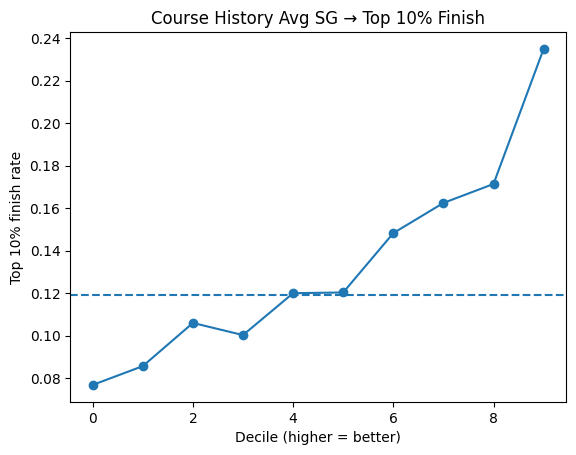

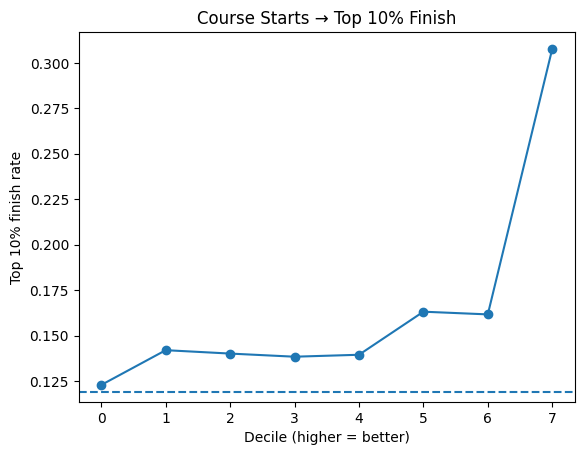

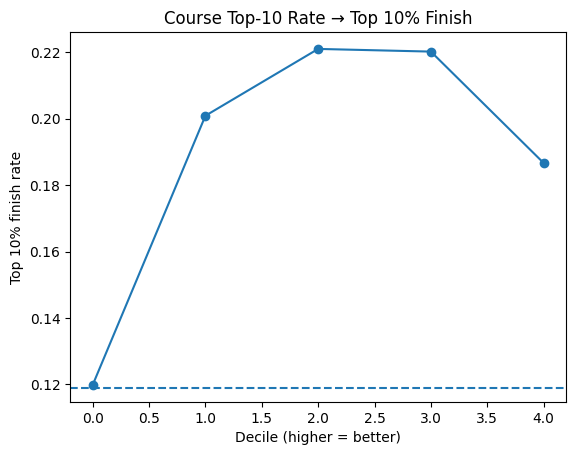

In [46]:
plot_lift(df_course, "pct_course_avg_sg_total", "Course History Avg SG → Top 10% Finish")

plot_lift(df_course, "pct_course_starts", "Course Starts → Top 10% Finish")

plot_lift(df_course, "pct_course_top10_rate", "Course Top-10 Rate → Top 10% Finish")

# ---

In [47]:
FORM_COL = "sg_total_L40_mean"  # or your preferred window

df_cs = model_df.copy()

# keep players with valid form + course history
df_cs = df_cs[
    df_cs[FORM_COL].notna() &
    df_cs["course_avg_sg_total"].notna()
].copy()

# restrict to top 40% recent form within each event
df_cs = df_cs[
    df_cs.groupby(["year","event_id"])[FORM_COL]
         .rank(pct=True) >= 0.60
]

In [48]:
course_lift_rows = []

for course_num, g in df_cs.groupby("course_num"):
    if g["course_avg_sg_total"].notna().sum() < 30:
        continue  # too sparse, skip

    g = g.copy()
    g["pct_course_sg"] = (
        g.groupby(["year","event_id"])["course_avg_sg_total"]
         .rank(pct=True)
    )

    dl = decile_lift(g, "pct_course_sg")

    top = dl.loc[dl["decile"] == dl["decile"].max(), "top10_rate"].iloc[0]
    lift = top / BASELINE

    course_lift_rows.append({
        "course_num": course_num,
        "events_used": g[["year","event_id"]].drop_duplicates().shape[0],
        "top_decile_top10_rate": top,
        "lift_vs_baseline": lift,
    })

course_sensitivity = (
    pd.DataFrame(course_lift_rows)
    .sort_values("lift_vs_baseline", ascending=False)
    .reset_index(drop=True)
)

display(course_sensitivity.head(15))

,course_num,events_used,top_decile_top10_rate,lift_vs_baseline
0,510,8,0.527778,4.433180
1,977,3,0.500000,4.199854
2,928,1,0.500000,4.199854
3,921,2,0.428571,3.599875
4,883,6,0.428571,3.599875
5,9,8,0.400000,3.359884
6,12,8,0.400000,3.359884
7,752,8,0.394737,3.315675
8,897,4,0.357143,2.999896
9,500,7,0.357143,2.999896


In [49]:
def classify_course(row):
    if row["lift_vs_baseline"] >= 1.6:
        return "history_sensitive"
    elif row["lift_vs_baseline"] <= 1.2:
        return "form_only"
    else:
        return "mixed"

course_sensitivity["course_type"] = course_sensitivity.apply(classify_course, axis=1)

course_sensitivity["course_type"].value_counts()

course_type
history_sensitive    26
form_only             5
mixed                 2
Name: count, dtype: int64

In [51]:
import pandas as pd
import numpy as np

def _pick_first_existing(df: pd.DataFrame, candidates: list[str]) -> str | None:
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    return None

def _find_form_col(df: pd.DataFrame, base: str = "sg_total", window: int = 12, stat: str = "mean") -> str | None:
    """
    Your rolling features look like: {base}_L{window}_{stat}
    ex: sg_total_L12_mean
    """
    target = f"{base}_L{window}_{stat}"
    return target if target in df.columns else None

def build_course_sensitivity_table(
    model_df: pd.DataFrame,
    min_samples: int = 150,
    outcome_col: str = "is_top10pct",
    course_col: str = "course_num",
    form_base: str = "sg_total",
    form_window: int = 12,
    form_stat: str = "mean",
    course_hist_candidates: list[str] | None = None,
) -> pd.DataFrame:
    """
    Builds per-course sensitivity using:
      - form signal: e.g., sg_total_L12_mean
      - course history signal: one of course_hist_candidates
      - outcome: is_top10pct (0/1)

    Returns columns:
      course_num, n_samples, corr_form, corr_course, course_type
    """

    if course_hist_candidates is None:
        # These are *examples*; update to match whatever you actually create for course history.
        course_hist_candidates = [
            "course_avg_sg_total",
            "course_sg_total_mean",
            "course_hist_sg_total",
            "prior_course_sg_total_mean",
        ]

    # ---- discover columns from schema ----
    form_col = _find_form_col(model_df, base=form_base, window=form_window, stat=form_stat)
    course_hist_col = _pick_first_existing(model_df, course_hist_candidates)

    missing = []
    if course_col not in model_df.columns: missing.append(course_col)
    if outcome_col not in model_df.columns: missing.append(outcome_col)
    if form_col is None: missing.append(f"{form_base}_L{form_window}_{form_stat}")
    if course_hist_col is None: missing.append(f"one of {course_hist_candidates}")

    if missing:
        # Print useful debug info
        print("Available columns (sample):", sorted(list(model_df.columns))[:60])
        raise KeyError(f"course sensitivity builder missing required columns: {missing}")

    rows = []
    for cnum, g in model_df.groupby(course_col):
        if len(g) < min_samples:
            continue

        form = pd.to_numeric(g[form_col], errors="coerce")
        course = pd.to_numeric(g[course_hist_col], errors="coerce")
        outcome = pd.to_numeric(g[outcome_col], errors="coerce")

        # require enough non-nan points for correlations to mean anything
        if form.notna().sum() < 40 or course.notna().sum() < 40 or outcome.notna().sum() < 40:
            continue

        corr_form = form.corr(outcome)
        corr_course = course.corr(outcome)

        # classification (simple + stable)
        # if either corr is nan, treat as mixed
        if pd.isna(corr_form) or pd.isna(corr_course):
            course_type = "mixed"
        elif corr_course > corr_form * 1.25:
            course_type = "history_sensitive"
        elif corr_form > corr_course * 1.25:
            course_type = "form_only"
        else:
            course_type = "mixed"

        rows.append({
            course_col: int(cnum) if pd.notna(cnum) else cnum,
            "n_samples": int(len(g)),
            "form_col": form_col,
            "course_hist_col": course_hist_col,
            "corr_form": float(corr_form) if pd.notna(corr_form) else np.nan,
            "corr_course": float(corr_course) if pd.notna(corr_course) else np.nan,
            "course_type": course_type,
        })

    out = pd.DataFrame(rows).sort_values(["course_type", "corr_course"], ascending=[True, False]).reset_index(drop=True)
    return out


In [53]:
course_sens_df = build_course_sensitivity_table(model_df)
course_sens_df.to_csv(
    "/Users/joshmacbook/python_projects/OAD/Data/Processed/course_sensitivity_table.csv",
    index=False,
)
course_sens_df.head(20)

,course_num,n_samples,form_col,course_hist_col,corr_form,corr_course,course_type
0,500,990,sg_total_L12_mean,course_avg_sg_total,0.201011,0.157370,form_only
1,9,987,sg_total_L12_mean,course_avg_sg_total,0.200686,0.154014,form_only
2,12,1094,sg_total_L12_mean,course_avg_sg_total,0.181873,0.141072,form_only
3,977,626,sg_total_L12_mean,course_avg_sg_total,0.177390,0.134640,form_only
4,503,1231,sg_total_L12_mean,course_avg_sg_total,0.218992,0.134240,form_only
5,885,312,sg_total_L12_mean,course_avg_sg_total,0.175023,0.132757,form_only
6,872,689,sg_total_L12_mean,course_avg_sg_total,0.214620,0.124058,form_only
7,876,1091,sg_total_L12_mean,course_avg_sg_total,0.190558,0.112279,form_only
8,23,991,sg_total_L12_mean,course_avg_sg_total,0.196867,0.111649,form_only
9,883,1088,sg_total_L12_mean,course_avg_sg_total,0.195445,0.106947,form_only
